--- SANITY CHECK FOR PHASE 2 (FACTORY RUN) ---

--- 1. VERIFYING FILE COUNTS ---
✅ Found 1750 total .npy feature files.
  - Train Files: 1250 (Expected: ~1250)
  - Test Files: 250 (Expected: ~250)
  - Validation Files: 250 (Expected: ~250)
✅ Total file count matches split counts.

--- 2. VERIFYING FILE CONTENT (Random Sample) ---
🔬 Inspecting random file: defense__defense_0007.npy
   Shape: (50, 7)
✅ Shape (50, 7) is CORRECT (50 frames, 7 features).
✅ File content appears valid (not empty or NaN).

--- 3. VISUALIZING FEATURE SIGNATURE ---
Plotting all 7 features over 50 frames for the random sample...


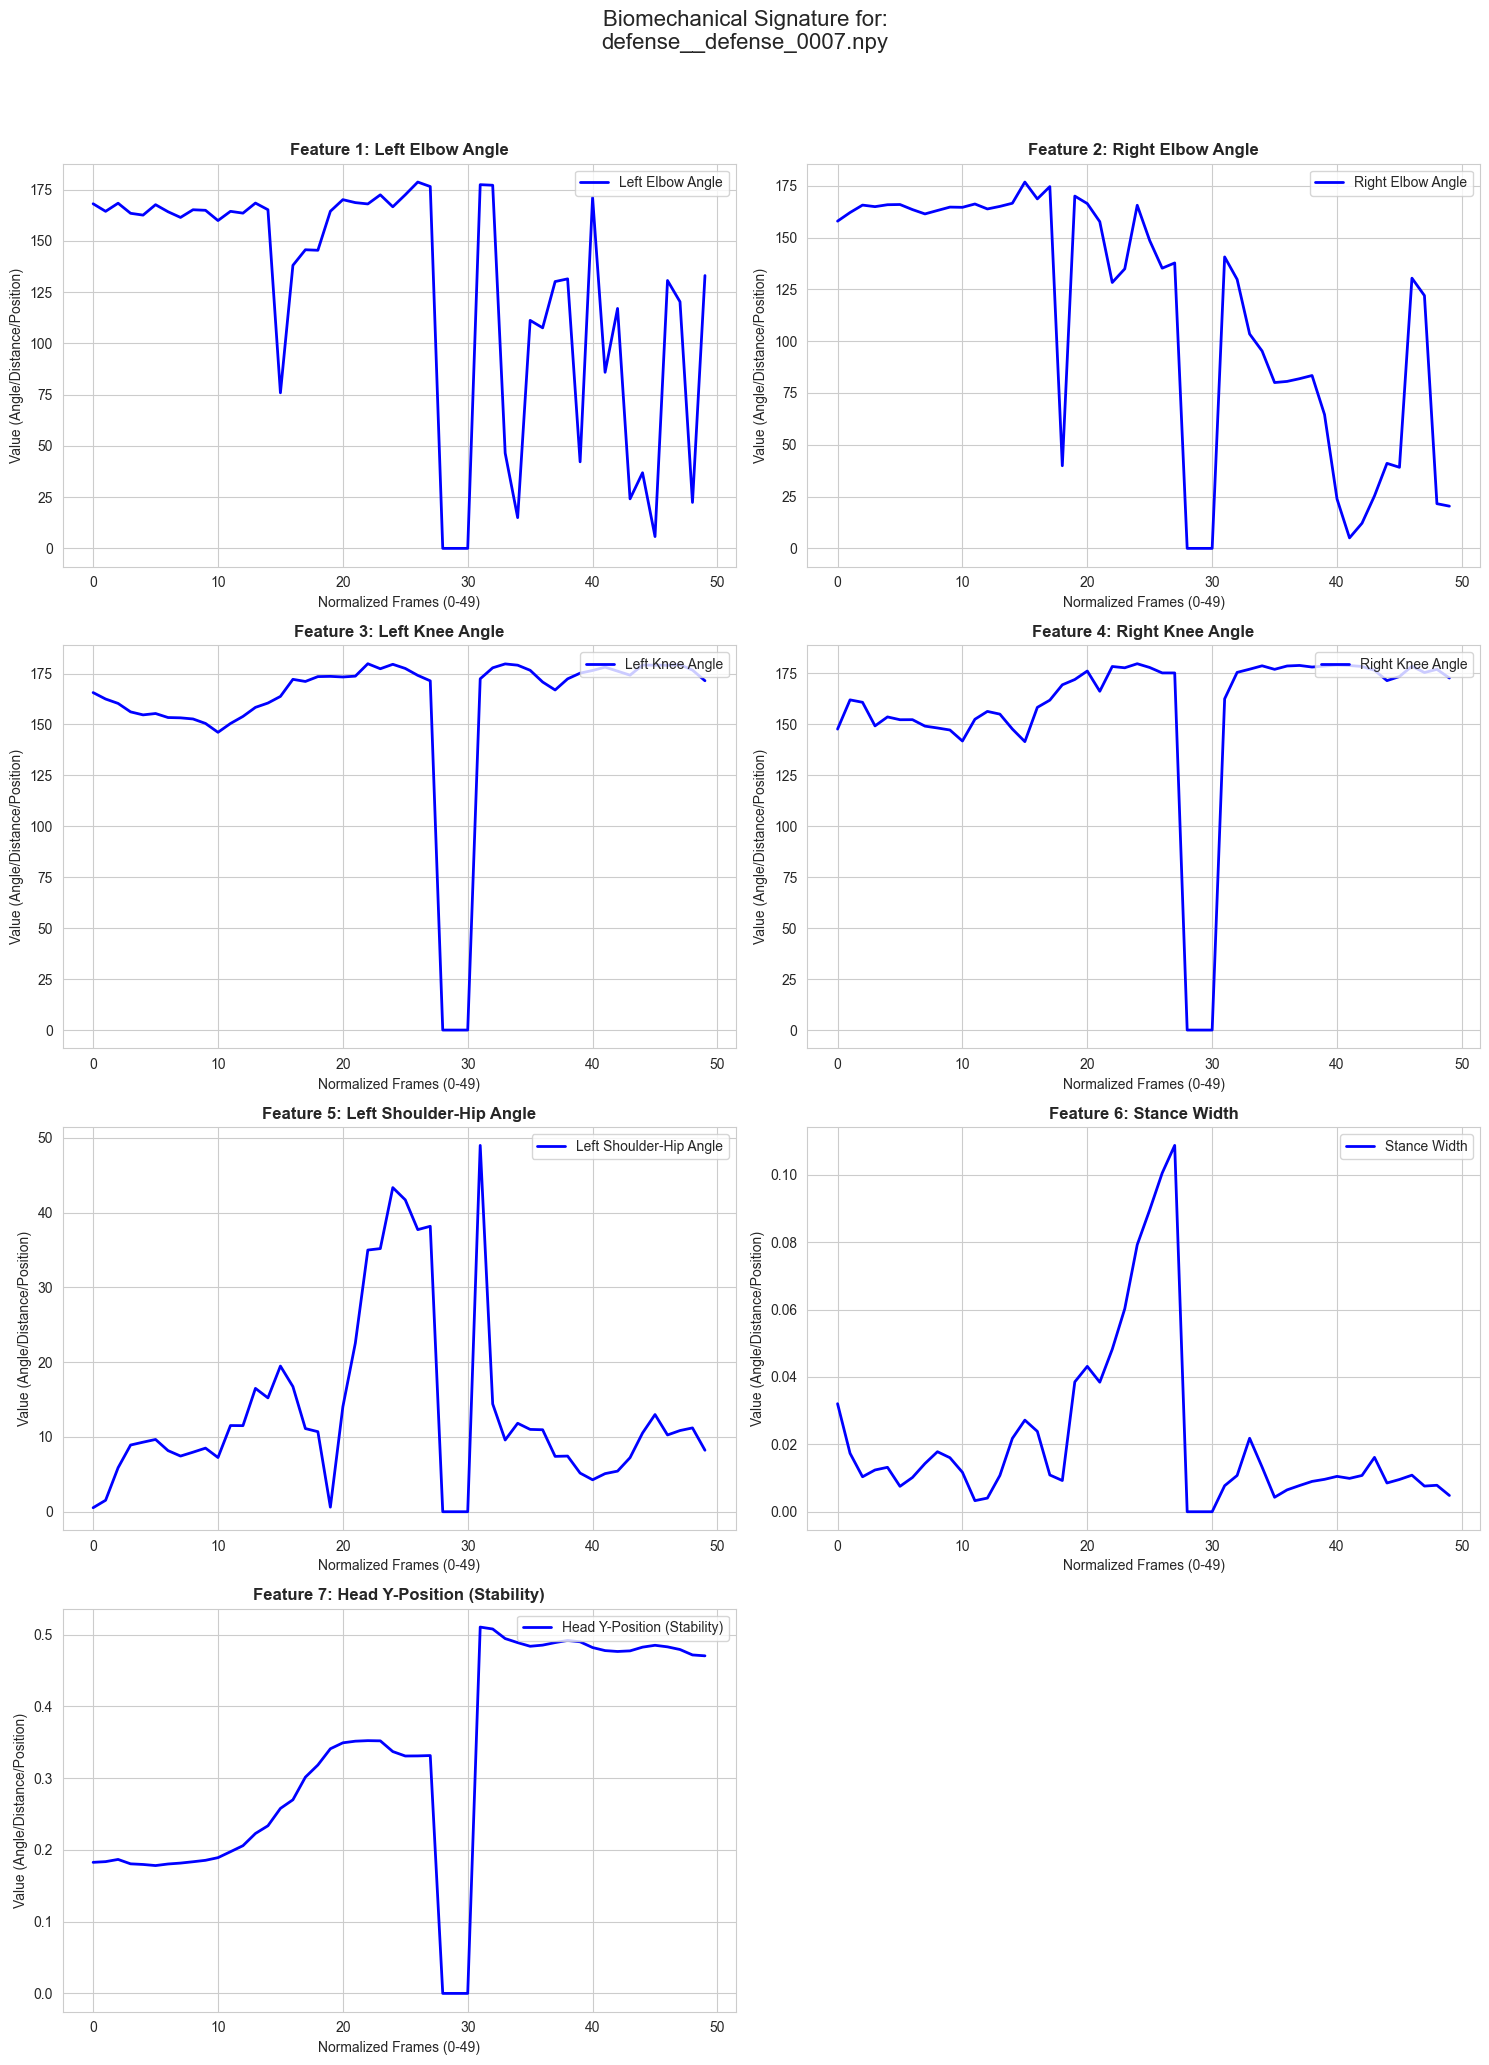


--- SANITY CHECK COMPLETE ---


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

print("--- SANITY CHECK FOR PHASE 2 (FACTORY RUN) ---")

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

FEATURE_DIR = os.path.join(PROJECT_ROOT, 'data', 'features', 'model_1_shot')

# These are the 7 features we extracted, IN ORDER.
FEATURE_LABELS = [
    "Left Elbow Angle",
    "Right Elbow Angle",
    "Left Knee Angle",
    "Right Knee Angle",
    "Left Shoulder-Hip Angle",
    "Stance Width",
    "Head Y-Position (Stability)"
]

# ==========================================
# 2. VERIFICATION 1: FILE COUNT
# ==========================================
print("\n--- 1. VERIFYING FILE COUNTS ---")
npy_files = glob.glob(os.path.join(FEATURE_DIR, '**', '*.npy'), recursive=True)

if len(npy_files) == 0:
    print("❌ CRITICAL ERROR: No .npy files found!")
    print(f"   Checked folder: {FEATURE_DIR}")
else:
    print(f"✅ Found {len(npy_files)} total .npy feature files.")
    
    # Check splits
    train_files = glob.glob(os.path.join(FEATURE_DIR, 'train', '**', '*.npy'), recursive=True)
    test_files = glob.glob(os.path.join(FEATURE_DIR, 'test', '**', '*.npy'), recursive=True)
    val_files = glob.glob(os.path.join(FEATURE_DIR, 'validation', '**', '*.npy'), recursive=True)

    print(f"  - Train Files: {len(train_files)} (Expected: ~1250)")
    print(f"  - Test Files: {len(test_files)} (Expected: ~250)")
    print(f"  - Validation Files: {len(val_files)} (Expected: ~250)")
    
    # Check if total matches sum
    if len(npy_files) == (len(train_files) + len(test_files) + len(val_files)):
        print("✅ Total file count matches split counts.")
    else:
        print("⚠️ Warning: Total file count does NOT match split counts. Check folders.")

# ==========================================
# 3. VERIFICATION 2: FILE CONTENT & SHAPE
# ==========================================
if npy_files:
    print("\n--- 2. VERIFYING FILE CONTENT (Random Sample) ---")
    
    # Load one random file
    random_file = random.choice(npy_files)
    data = np.load(random_file)
    
    print(f"🔬 Inspecting random file: {os.path.basename(random_file)}")
    print(f"   Shape: {data.shape}")
    
    if data.shape == (50, 7):
        print("✅ Shape (50, 7) is CORRECT (50 frames, 7 features).")
        
        # Check for bad data
        if np.all(data == 0):
            print("❌ ERROR: This file is ALL ZEROS. Check your 'process_video' function.")
        elif np.isnan(data).any():
            print("❌ ERROR: This file contains NaN (Not-a-Number) values.")
        else:
            print("✅ File content appears valid (not empty or NaN).")

# ==========================================
# 4. VERIFICATION 3: VISUAL PROOF (THE GRAPHS)
# ==========================================
if npy_files and data.shape == (50, 7) and not np.all(data == 0):
    print("\n--- 3. VISUALIZING FEATURE SIGNATURE ---")
    print("Plotting all 7 features over 50 frames for the random sample...")
    
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    axes = axes.flatten() # Make the 4x2 grid easy to loop through
    
    for i in range(7):
        feature_name = FEATURE_LABELS[i]
        feature_data = data[:, i] # Get all 50 frames for this one feature
        
        ax = axes[i]
        ax.plot(feature_data, label=feature_name, color='blue', linewidth=2)
        ax.set_title(f"Feature {i+1}: {feature_name}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Normalized Frames (0-49)")
        ax.set_ylabel("Value (Angle/Distance/Position)")
        ax.legend(loc='upper right')

    # Delete the last (empty) subplot
    fig.delaxes(axes[7])
    
    fig.suptitle(f"Biomechanical Signature for:\n{os.path.basename(random_file)}", fontsize=16, y=1.03)
    plt.tight_layout()
    plt.show()

else:
    print("\n--- 3. VISUALIZING FEATURE SIGNATURE ---")
    print("SKIPPED: Cannot draw graphs because file count or shape is incorrect.")

print("\n--- SANITY CHECK COMPLETE ---")